In [23]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
import pandas as pd
import os


In [24]:
os.chdir(r"C:\Users\sejal\IDX\IDX-Exchange-Data-Science")

In [25]:
#using data from 05/2025 to 04/2026
files = [
    "Data/CRMLSSold202505.csv",
    "Data/CRMLSSold202506.csv",
    "Data/CRMLSSold202507.csv",
    "Data/CRMLSSold202508.csv",
    "Data/CRMLSSold202509.csv",
    "Data/CRMLSSold202510.csv",
    "Data/CRMLSSold202511.csv",
    "Data/CRMLSSold202512.csv",
    "Data/CRMLSSold202601.csv",
    "Data/CRMLSSold202602.csv",
    "Data/CRMLSSold202603.csv",
    "Data/CRMLSSold202604.csv"
]

#load
all_data = []

for file in files:
    temp = pd.read_csv(file, low_memory=False)
    all_data.append(temp)

#combine
df = pd.concat(all_data, ignore_index=True)
#shape

print(df.shape)
df["CloseDate"] = pd.to_datetime(df["CloseDate"])
print(df["CloseDate"].min())
print(df["CloseDate"].max())

(261087, 80)
2025-05-01 00:00:00
2026-04-30 00:00:00


In [26]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChangeDate', 'Eleme

In [27]:
df["Month"] = df["CloseDate"].dt.to_period("M")
df["Month"].value_counts().sort_index()
df["Month"].nunique()

12

In [28]:
# Review each column's data type, amount of missing data,
# and number of unique values.
column_review = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique_values": df.nunique()
})


display(column_review.sort_values("missing_pct", ascending=False))

print("Duplicate rows:", df.duplicated().sum())
print("Repeated ListingKeys:", df["ListingKey"].duplicated().sum())

,dtype,missing_count,missing_pct,unique_values
FireplacesTotal,float64,261087,100.0,0
ElementarySchoolDistrict,float64,261087,100.0,0
CoveredSpaces,float64,261087,100.0,0
AboveGradeFinishedArea,float64,261087,100.0,0
MiddleOrJuniorSchoolDistrict,float64,261087,100.0,0
...,...,...,...,...
MlsStatus,object,0,0.0,1
PropertyType,object,0,0.0,8
ContractStatusChangeDate,object,0,0.0,365
StateOrProvince,object,0,0.0,18


Duplicate rows: 37
Repeated ListingKeys: 190


In [29]:
#lets also check residential and single family residence rows and invesitgate their values
eda_df = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

print("Rows before filtering:", len(df))
print("Rows after filtering:", len(eda_df))

print(eda_df["PropertyType"].value_counts())
print(eda_df["PropertySubType"].value_counts())

Rows before filtering: 261087
Rows after filtering: 131226
PropertyType
Residential    131226
Name: count, dtype: int64
PropertySubType
SingleFamilyResidence    131226
Name: count, dtype: int64


This reuslt above just shows that filtering for Residential and then sub filtering to single family residence brings out rows from 261,087 to 131,226. We will use this for remaining EDA.

In [30]:
#checking the main numeric columns for outliers and distributions
numeric_cols = [
    "ClosePrice", "ListPrice", "LivingArea",
    "DaysOnMarket", "BedroomsTotal", "BathroomsTotalInteger"
]

display(eda_df[numeric_cols].describe())

,ClosePrice,ListPrice,LivingArea,DaysOnMarket,BedroomsTotal,BathroomsTotalInteger
count,1.312260e+05,1.312260e+05,131153.000000,131226.000000,131226.000000,131213.000000
mean,1.335888e+06,1.263085e+06,2046.343384,40.401026,3.490848,2.629678
std,7.993635e+06,1.614106e+06,1043.851673,52.999123,0.964508,1.131773
min,0.000000e+00,8.000000e+03,0.000000,-265.000000,0.000000,0.000000
25%,6.249975e+05,6.250000e+05,1385.000000,8.000000,3.000000,2.000000
50%,8.880000e+05,8.900000e+05,1817.000000,20.000000,3.000000,2.000000
75%,1.410000e+06,1.399000e+06,2438.000000,53.000000,4.000000,3.000000
max,9.895000e+08,1.375000e+08,56500.000000,2177.000000,22.000000,35.000000


Here we are a little suspicious of the maximum value for Close Price, potential a closing price of $989,500,000 is odd, but there might be an explanation so lets investigate further.

The negative value for the minimum days on the market is very suspicious, it either means incorrect data or data has some potential issues. Lets invesitgate this next.

In [31]:
display(
    eda_df.loc[df["DaysOnMarket"] < 0, [
        "ListingKey",
        "CloseDate",
        "ListingContractDate",
        "PurchaseContractDate",
        "DaysOnMarket",
        "PropertyType"
    ]]
)
print("Negative DaysOnMarket:", (eda_df["DaysOnMarket"] < 0).sum())
print("Zero ClosePrice:", (eda_df["ClosePrice"] == 0).sum())
print("Zero LivingArea:", (eda_df["LivingArea"] == 0).sum())

,ListingKey,CloseDate,ListingContractDate,PurchaseContractDate,DaysOnMarket,PropertyType
21617,1095580381,2025-05-15,2024-11-21,2025-03-22,-34,Residential
32260,1112514824,2025-06-23,2025-05-01,2025-06-13,-26,Residential
42149,1108279128,2025-06-17,2025-03-04,2025-04-27,-7,Residential
61461,1112882699,2025-07-03,2025-05-07,2025-07-01,-9,Residential
67807,1107324362,2025-07-24,2025-02-12,2025-07-15,-63,Residential
87908,1112971484,2025-08-29,2025-05-08,2025-08-03,-14,Residential
120464,1133974483,2025-10-23,2025-08-13,2025-09-26,-7,Residential
123354,1131827231,2025-10-29,2025-09-03,2025-09-29,-2,Residential
131480,1119659079,2025-10-27,2025-07-18,2025-10-21,-4,Residential
137202,1109524000,2025-10-10,2025-03-31,2025-07-29,-21,Residential


Negative DaysOnMarket: 15
Zero ClosePrice: 1
Zero LivingArea: 61


Here we see that the date themselves are quite reasonable, looking at Listing Contract date we see appropriate dates. This must means that days on market might've been generated off of some rules that are unknown (warned in primer that DOM can behave differently it it was relisted or it was listed as back-on-market). Let calculate the date difference and try to understand them independently, so lets calculate the number of days from listing to purchase for those specific 19 listings and compare again.

In [32]:
#since both ListingContractDate and PurchaseContractDate are strings
# we need to convert to datetime for calculations

#lets also use errors="coerce" just to force weird values to becoming nulls instead of throwing errors

eda_df["ListingContractDate"] = pd.to_datetime(eda_df["ListingContractDate"], errors="coerce")
eda_df["PurchaseContractDate"] = pd.to_datetime(eda_df["PurchaseContractDate"], errors="coerce")
eda_df["CloseDate"] = pd.to_datetime(eda_df["CloseDate"], errors="coerce")

eda_df["CalculatedDOM"] = (
    eda_df["PurchaseContractDate"] - eda_df["ListingContractDate"]
).dt.days
#narrow down search to those 19
negative_dom = eda_df[eda_df["DaysOnMarket"] < 0].copy()

display(
    negative_dom[
        [
            "ListingKey",
            "ListingContractDate",
            "PurchaseContractDate",
            "CloseDate",
            "DaysOnMarket",
            "CalculatedDOM",
            "PropertyType"
        ]
    ]
)

,ListingKey,ListingContractDate,PurchaseContractDate,CloseDate,DaysOnMarket,CalculatedDOM,PropertyType
21617,1095580381,2024-11-21,2025-03-22,2025-05-15,-34,121.0,Residential
32260,1112514824,2025-05-01,2025-06-13,2025-06-23,-26,43.0,Residential
42149,1108279128,2025-03-04,2025-04-27,2025-06-17,-7,54.0,Residential
61461,1112882699,2025-05-07,2025-07-01,2025-07-03,-9,55.0,Residential
67807,1107324362,2025-02-12,2025-07-15,2025-07-24,-63,153.0,Residential
87908,1112971484,2025-05-08,2025-08-03,2025-08-29,-14,87.0,Residential
120464,1133974483,2025-08-13,2025-09-26,2025-10-23,-7,44.0,Residential
123354,1131827231,2025-09-03,2025-09-29,2025-10-29,-2,26.0,Residential
131480,1119659079,2025-07-18,2025-10-21,2025-10-27,-4,95.0,Residential
137202,1109524000,2025-03-31,2025-07-29,2025-10-10,-21,120.0,Residential


Calculated DOM is now showing us positive values and is now accurately representing the amount of time the properties spend on the market. This shows the dates themselve produce sensible positive durations, but the original column had simply contained negative values. We are simply going to flag these 19 points for data preprocessing

In [33]:
#flags
eda_df["InvalidDOM"] = eda_df["DaysOnMarket"] < 0

In [34]:
# Missingness and column types
column_review = pd.DataFrame({
    "dtype": eda_df.dtypes,
    "missing_count": eda_df.isna().sum(),
    "missing_pct": eda_df.isna().mean().mul(100),
    "unique_values": eda_df.nunique()
})
display(column_review.sort_values("missing_pct", ascending=False))

# Missingness within each property type
display(
    eda_df.groupby("PropertyType").apply(
        lambda group: group.isna().mean().mul(100),
        include_groups=False
    ).T
)

# Identical extra rows
print("Identical extra rows:", eda_df.duplicated().sum())

# Show every occurrence of repeated, nonmissing keys
repeated_keys = eda_df.loc[ 
    eda_df["ListingKey"].notna()
    & eda_df["ListingKey"].duplicated(keep=False)
].sort_values(["ListingKey", "CloseDate"])

display(repeated_keys[
    ["ListingKey", "ListingId", "PropertyType",
     "CloseDate", "ClosePrice", "UnparsedAddress"]
])

,dtype,missing_count,missing_pct,unique_values
TaxAnnualAmount,float64,131226,100.0,0
FireplacesTotal,float64,131226,100.0,0
AboveGradeFinishedArea,float64,131226,100.0,0
TaxYear,float64,131226,100.0,0
ElementarySchoolDistrict,float64,131226,100.0,0
...,...,...,...,...
ListingContractDate,datetime64[ns],0,0.0,893
StateOrProvince,object,0,0.0,5
BedroomsTotal,float64,0,0.0,19
Month,period[M],0,0.0,12


PropertyType,Residential
BuyerAgentAOR,2.579519
ListAgentAOR,0.016765
Flooring,35.673571
ViewYN,9.063753
WaterfrontYN,99.948181
...,...
OriginatingSystemName,74.844162
OriginatingSystemSubName,74.844162
Month,0.000000
CalculatedDOM,0.004572


Identical extra rows: 6


,ListingKey,ListingId,PropertyType,CloseDate,ClosePrice,UnparsedAddress
45856,1075843364,OR24107765,Residential,2025-06-20,750000.0,19593 Lexington Avenue
92548,1075843364,OR24107765,Residential,2025-08-20,750000.0,19593 Lexington Avenue
22895,1076103978,PW24114002,Residential,2025-05-05,1339000.0,139 Jessup Way
45839,1076103978,PW24114002,Residential,2025-06-03,1290000.0,139 Jessup Way
21115,1100602206,HD24253013,Residential,2025-05-26,605000.0,18805 Ranchero Road
...,...,...,...,...,...,...
252988,1152484608,CV26023477,Residential,2026-04-02,410000.0,4944 Oakhurst
218590,1153089900,OC26035173,Residential,2026-03-28,1300000.0,1011 Inspiration Lane
251123,1153089900,OC26035173,Residential,2026-04-10,1295000.0,1011 Inspiration Lane
217833,1153224581,AR26037348,Residential,2026-03-28,1610000.0,3398 Heather Field Drive


,listing_rows
PropertyType,
Residential,131226


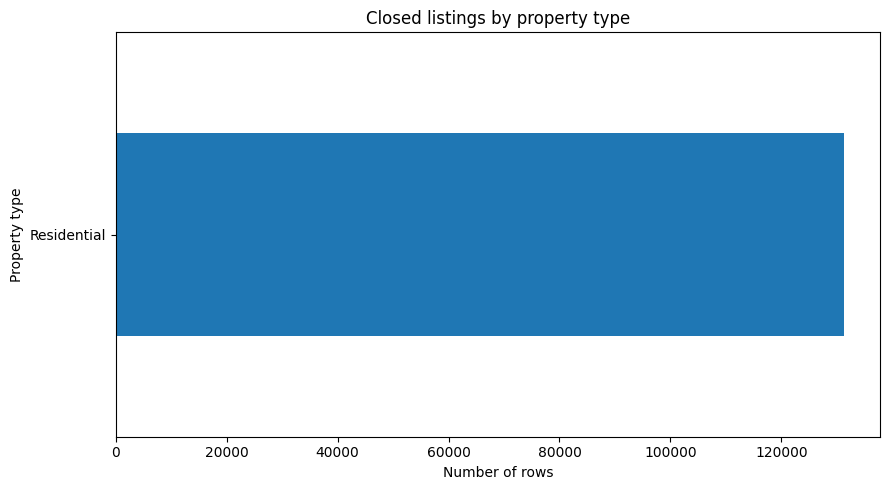

In [35]:
#invesitgating property types and their distributions
property_counts = eda_df["PropertyType"].value_counts(dropna=False)
display(property_counts.rename("listing_rows").to_frame())

property_counts.sort_values().plot(
    kind="barh", figsize=(9, 5),
    title="Closed listings by property type"
)
plt.xlabel("Number of rows")
plt.ylabel("Property type")
plt.tight_layout()
plt.show()

After investigating it seems sensible to restrict closing price to residential closing prices only as it has the least issues in terms of data, other property types differ in terms of size, price, and purpose.

Rows before filtering: 261087
Single-family residential rows: 131226
Missing or nonpositive prices excluded: 1


count    1.312250e+05
mean     1.335898e+06
std      7.993664e+06
min      1.750000e+00
1%       2.350000e+05
25%      6.249990e+05
50%      8.880000e+05
75%      1.410000e+06
99%      6.400000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64

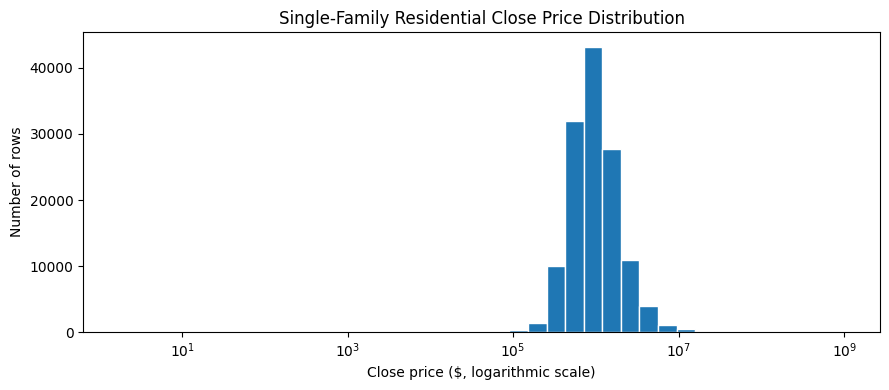

In [36]:
#invesitagating the distribution of close prices, lets also filter the data to Residential and singe family residence as instructed
# Investigate the distribution of ClosePrice for the required
sfh = eda_df.loc[
    (eda_df["PropertyType"] == "Residential") &
    (eda_df["PropertySubType"] == "SingleFamilyResidence")
].copy()

#quick check
print("Rows before filtering:", len(df))
print("Single-family residential rows:", len(sfh))

#here we need to  converst all close prices to numeric format and exclude negative or missing prices 
#helpful for plotting and calculating summary statistics
prices = pd.to_numeric(sfh["ClosePrice"], errors="coerce")
valid_prices = prices.loc[prices.notna() & prices.gt(0)]


print("Missing or nonpositive prices excluded:", len(prices) - len(valid_prices))
display(valid_prices.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]))

if not valid_prices.empty:
    # Log-spaced bins show a wide price range (also easier to visualize and read) without removing extreme values.
    low, high = valid_prices.min(), valid_prices.max()
    bins = np.geomspace(low, high, 40) if high > low else 10

    plt.figure(figsize=(9, 4))
    plt.hist(valid_prices, bins=bins, edgecolor="white")
    plt.xscale("log")
    # Residential and SingleFamilyResidence subset.
    plt.title("Single-Family Residential Close Price Distribution")
    plt.xlabel("Close price ($, logarithmic scale)")
    plt.ylabel("Number of rows")
    plt.tight_layout()
    plt.show()

Residential rows after outlier removal: 128650


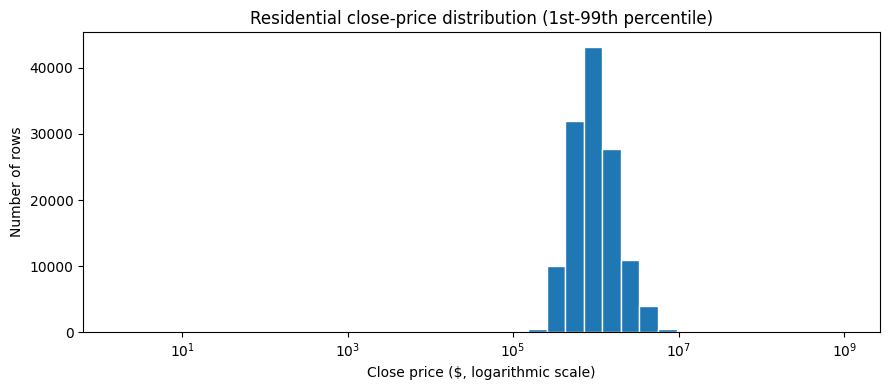

In [37]:
# Zoom in on the 1st-99th percentile for visualization
# This does not remove outliers from eda_df
q_low = valid_prices.quantile(0.01)
q_high = valid_prices.quantile(0.99)
valid_prices = valid_prices.loc[valid_prices.between(q_low, q_high)]
print("Residential rows after outlier removal:", len(valid_prices))
plt.figure(figsize=(9, 4))
plt.hist(valid_prices, bins=bins, edgecolor="white")
plt.xscale("log")
plt.title("Residential close-price distribution (1st-99th percentile)")
plt.xlabel("Close price ($, logarithmic scale)")
plt.ylabel("Number of rows")
plt.tight_layout()
plt.show()


Finally let us do some basic distributions for the importatn numerical variables, lets so some analysis on closeprice , living area, bedrooms, and bathrooms. We see bathroom has some listings with 0 bathrooms, this is a little unsual so we will investigate it further.

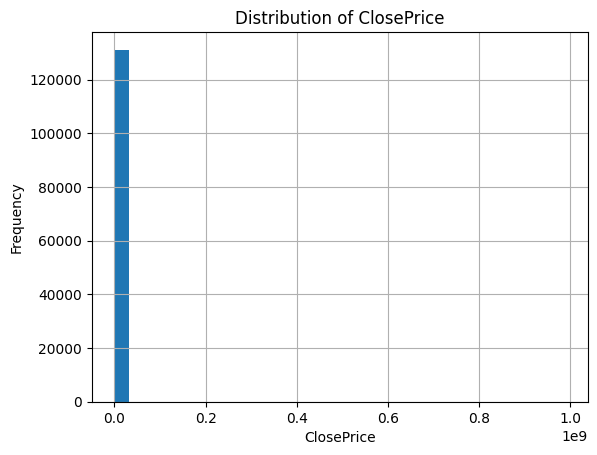

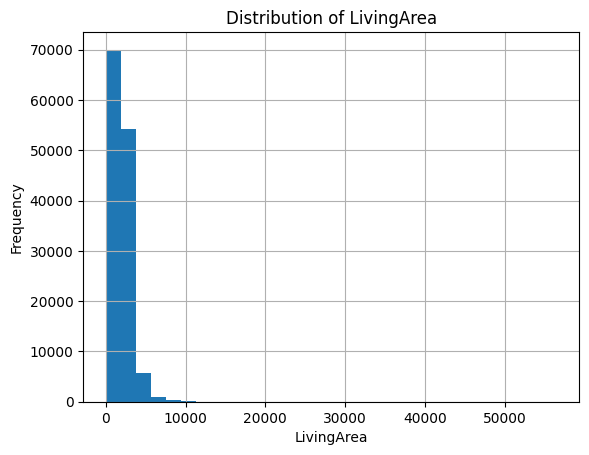

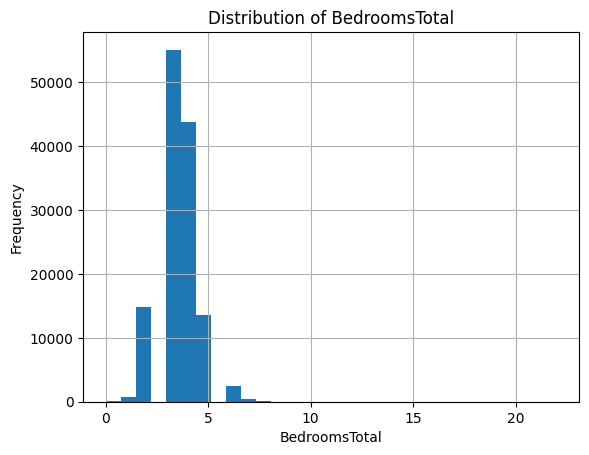

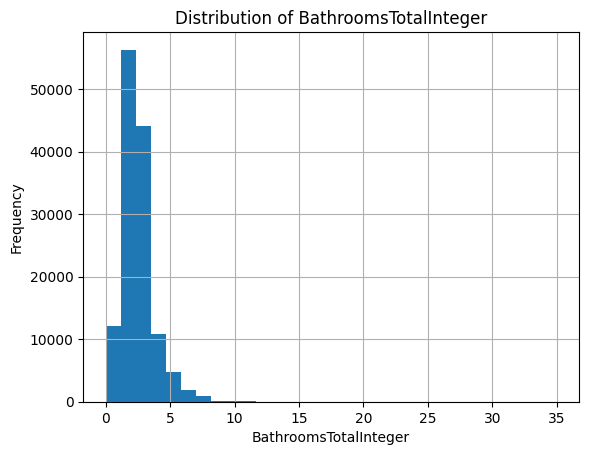

In [38]:
columns = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger"
    
]

for column in columns:
    eda_df[column].hist(bins=30)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [46]:
zero_baths = sfh[sfh["BathroomsTotalInteger"] == 0].copy()

print("Single-family homes with 0 bathrooms:", len(zero_baths))

display(
    zero_baths[
        [
            "ListingKey",
            "ClosePrice",
            "LivingArea",
            "BedroomsTotal",
            "BathroomsTotalInteger",
            "YearBuilt",
            "City",
            "UnparsedAddress"
        ]
    ].head(30)
)

Single-family homes with 0 bathrooms: 57


,ListingKey,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,YearBuilt,City,UnparsedAddress
742,1113133160,28666667.0,NaN,0.0,0.0,NaN,Los Angeles,375 N Carolwood Drive
949,1113028285,762000.0,1246.0,3.0,0.0,1948.0,La Mesa,6934 Ohio Ave
1254,1112905774,2125390.0,0.0,0.0,0.0,NaN,Rancho Mirage,4 Marine Way
6713,1111677789,600000.0,NaN,0.0,0.0,1958.0,Altadena,2775 Lake Avenue
7762,1111554207,625000.0,0.0,0.0,0.0,1951.0,Altadena,3054 Santa Anita Avenue
8421,1111443101,570000.0,0.0,0.0,0.0,1952.0,Altadena,591 Mount Curve Avenue
19521,1104106961,1640000.0,100.0,0.0,0.0,1973.0,Manhattan Beach,1300 Oak Avenue
21590,1095841754,2700000.0,5744.0,0.0,0.0,NaN,Venice,506 Westminster Avenue
24088,1115087921,925000.0,0.0,0.0,0.0,1968.0,Pasadena,3680 Startouch Drive
25898,1114585930,550000.0,1056.0,0.0,0.0,1922.0,Altadena,3133 Ewing Avenue


We see incomplete records and some missing data. Lets flag that data for later review in data preprocessing.

In [48]:
#flags
sfh["Flag_ZeroBathrooms"] = sfh["BathroomsTotalInteger"] == 0
#checks

print("0 bathrooms and 0 bedrooms:",
      ((sfh["BathroomsTotalInteger"] == 0) &
       (sfh["BedroomsTotal"] == 0)).sum())

print("0 bathrooms and missing/zero living area:",
      ((sfh["BathroomsTotalInteger"] == 0) &
       (sfh["LivingArea"].fillna(0) == 0)).sum())

0 bathrooms and 0 bedrooms: 45
0 bathrooms and missing/zero living area: 21


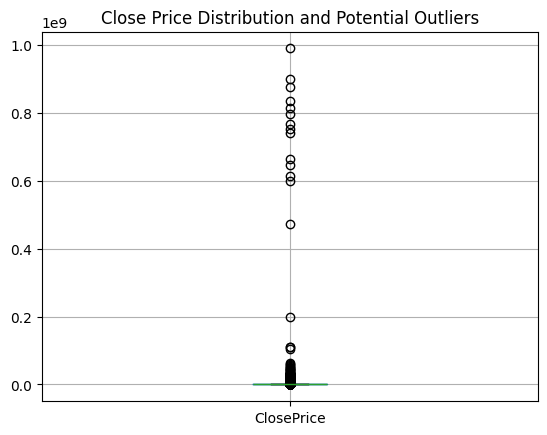

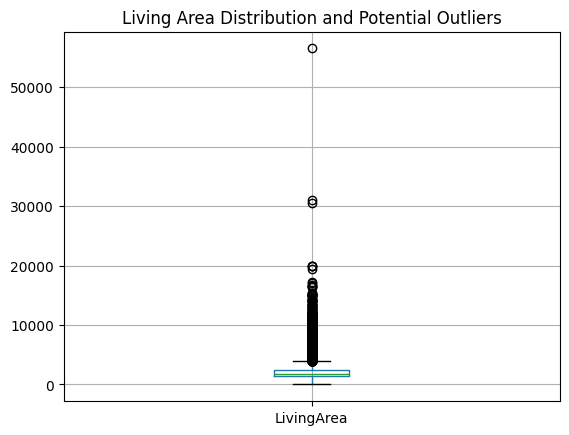

In [42]:
#lets also look at some outliers for close price and living area before taking any other actions
eda_df.boxplot(column="ClosePrice")
plt.title("Close Price Distribution and Potential Outliers")
plt.show()

eda_df.boxplot(column="LivingArea")
plt.title("Living Area Distribution and Potential Outliers")
plt.show()

Observations:

Here we see that we have some issues with the numerical data. We can see that they are not evenly distributed as ClosePrice is extremely Right Skewed. This means that the small number of listings with extremely expensive closing prices is pulling the distribution dramatically. We will invesigate this further or possible transform the variables to help evenly represent the data.

We also see that living area is right skewed as well, the dataset includes unusually large home with listings being listed with 50,000+ square feet, we need to observe this futher before we can make any decisions.

Both bedrooms and bathrooms are alsow right skewed which tells use we will need to invesitgate into these variables a little more. This so far is telling us we might have some data quality issues or unusually large properties.

Finally for the outliers we observe the boxplots, here we see many potential outliers in both box plots which futher supports that we must invesitgate out numerical data further to determine if these values are valid or invalid. We see for closeprice that there are values with hundreds of millions of dollars and livingarea contains many large properties. There is a possibility of these listings being luxury properties so we will not blindly remove them, instead let's examin these values individually during data preprocessing.

In [43]:
#some more basic investigation of the data, lets look at the largets 15 listing for close prices and living area
display(
    eda_df.nlargest(15, "ClosePrice")[
        [
            "ListingKey",
            "ClosePrice",
            "LivingArea",
            "BedroomsTotal",
            "BathroomsTotalInteger",
            "City",
            "PostalCode"
        ]
    ]
)
display(
    eda_df.nlargest(15, "LivingArea")[
        [
            "ListingKey",
            "ClosePrice",
            "LivingArea",
            "BedroomsTotal",
            "BathroomsTotalInteger",
            "City",
            "PostalCode"
        ]
    ]
)

,ListingKey,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,City,PostalCode
120940,1133720285,989500000.0,2289.0,5.0,3.0,Valencia,91355
45801,1076630163,900000000.0,11000.0,13.0,10.0,Glennville,93287
92732,1136956787,875000000.0,1730.0,4.0,2.0,San Diego,92117
99409,1125862013,835800000.0,718.0,1.0,1.0,Ramona,92065
110014,1115065523,815000000.0,1900.0,4.0,3.0,Saugus,91350
257276,1149697906,796000000.0,1936.0,2.0,3.0,Valley Center,92082
256360,1150712418,768500000.0,1444.0,4.0,2.0,San Diego,92154
94116,1131758129,751412000.0,798.0,2.0,1.0,La Mesa,91942
152561,1126046881,740000000.0,1271.0,3.0,2.0,San Diego,92154
231051,1148201765,664250000.0,1992.0,4.0,3.0,Chula Vista,91911


,ListingKey,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,City,PostalCode
69672,1032371159,110000000.0,56500.0,14.0,27.0,Los Angeles,90024
156836,1108565800,28000000.0,31068.0,19.0,23.0,Rancho Santa Fe,92067
41675,1108476202,63100000.0,30500.0,12.0,20.0,Beverly Hills,90210
45332,1090174200,13500000.0,20000.0,9.0,11.0,Los Angeles,90027
68396,1103389607,19000000.0,20000.0,6.0,11.0,Malibu,90265
109952,1115099459,44000000.0,20000.0,8.0,14.0,Los Angeles,90049
222794,1152160462,30260000.0,19474.0,7.0,15.0,Beverly Hills,90210
211731,1127472951,8000000.0,17153.0,10.0,13.0,Bradbury,91008
71263,1123199296,47500000.0,17005.0,7.0,15.0,Beverly Hills,90210
137885,1102934910,11515000.0,16683.0,8.0,12.0,La Jolla,92037


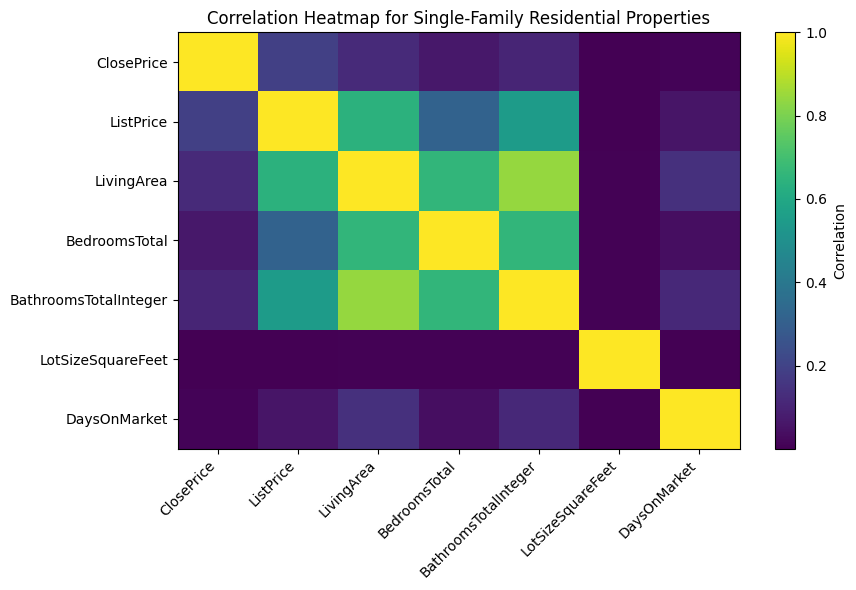

In [44]:
# Check correlations between important numerical features
heatmap_cols = [
    "ClosePrice",
    "ListPrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "DaysOnMarket"
]

corr = sfh[heatmap_cols].corr()

plt.figure(figsize=(9, 6))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(heatmap_cols)), heatmap_cols, rotation=45, ha="right")
plt.yticks(range(len(heatmap_cols)), heatmap_cols)
plt.colorbar(label="Correlation")

plt.title("Correlation Heatmap for Single-Family Residential Properties")
plt.tight_layout()
plt.show()

Looking at the table for closing prices we can clearly see there is some data discrepencies, a closing prices for a property with 2,289 square feet, 5 bedrooms, and 3 bathrooms is listed for $985.5 million which is highly unlikely. A lot of properties with only 700-1900 sq ft have extreme closing prices, so lets flag these values as potential data errors.


Looking at the table for living area, we can see the extreme data is listed as unsually high prices, being located in areas like Malibu, Beverly Hills, Los Angeles, and others alongside having 6-19 bedrooms and 10-27 bathrooms. This further supports the data simply having luxury housing than these observations being incorrect data. We will use dataprocessing to determine if we should remove or transform these variables now.

In [45]:
# Flag unusually high closing prices for later investigation
eda_df["HighClosePriceFlag"] = eda_df["ClosePrice"] >= 100_000_000

print("Flagged high ClosePrice records:",
      eda_df["HighClosePriceFlag"].sum())

Flagged high ClosePrice records: 18
